notebook for testing functions as they migrate from notebook to src/

In [11]:
# imports
from src.data.loader import (
	load_dataset, 
	load_raw
)
from src.visualization.data_visualization import (
	plot_label_distribution,
	plot_correlation_heatmap,
	plot_correlated_pairs
)

from src.data.resampler import resample

from src.models.evaluation import evaluate_and_visualize
import numpy as np
import pandas as pd

In [2]:
# load data
df = load_dataset()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading cleaned dataset from cache at cache/cleaned.parquet
Shape: (2522362, 62)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 

In [3]:
# verify cleaning was applied
assert df.isnull().sum().sum() == 0, "Data contains missing values"
assert 'Label' in df.columns, "Label column is missing"
assert df.shape[1] == 62, f"Expected 62 columns after cleaning, got {df.shape[1]}"
print("Data loading and verification successful.")

Data loading and verification successful.


Loading raw dataset from Kaggle...
Raw shape: 2,830,743 rows, 79 columns


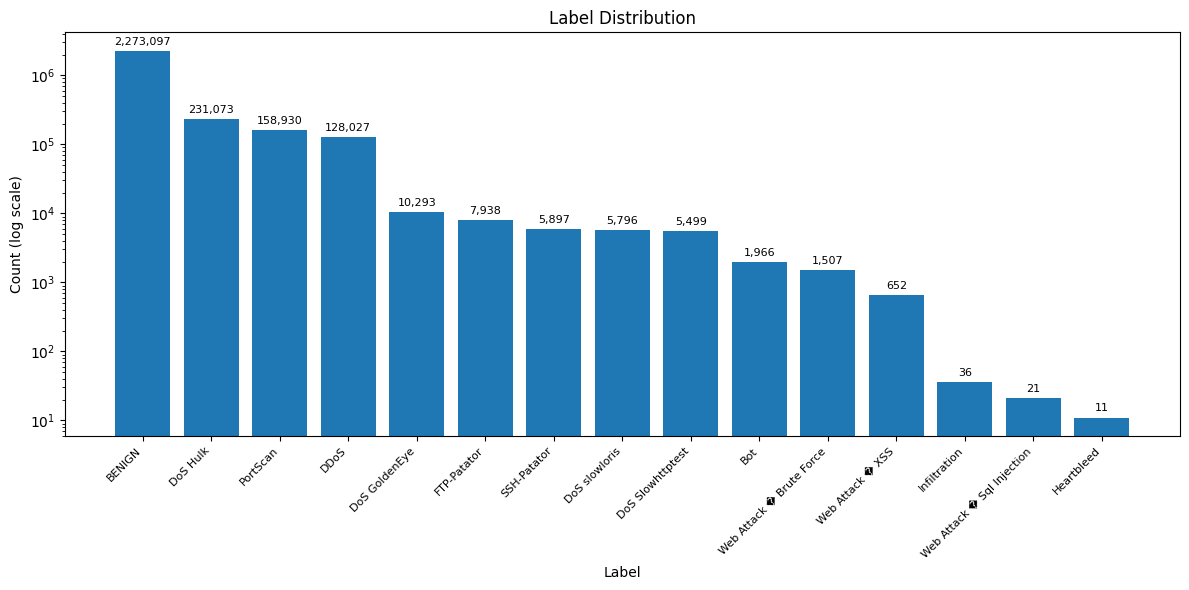

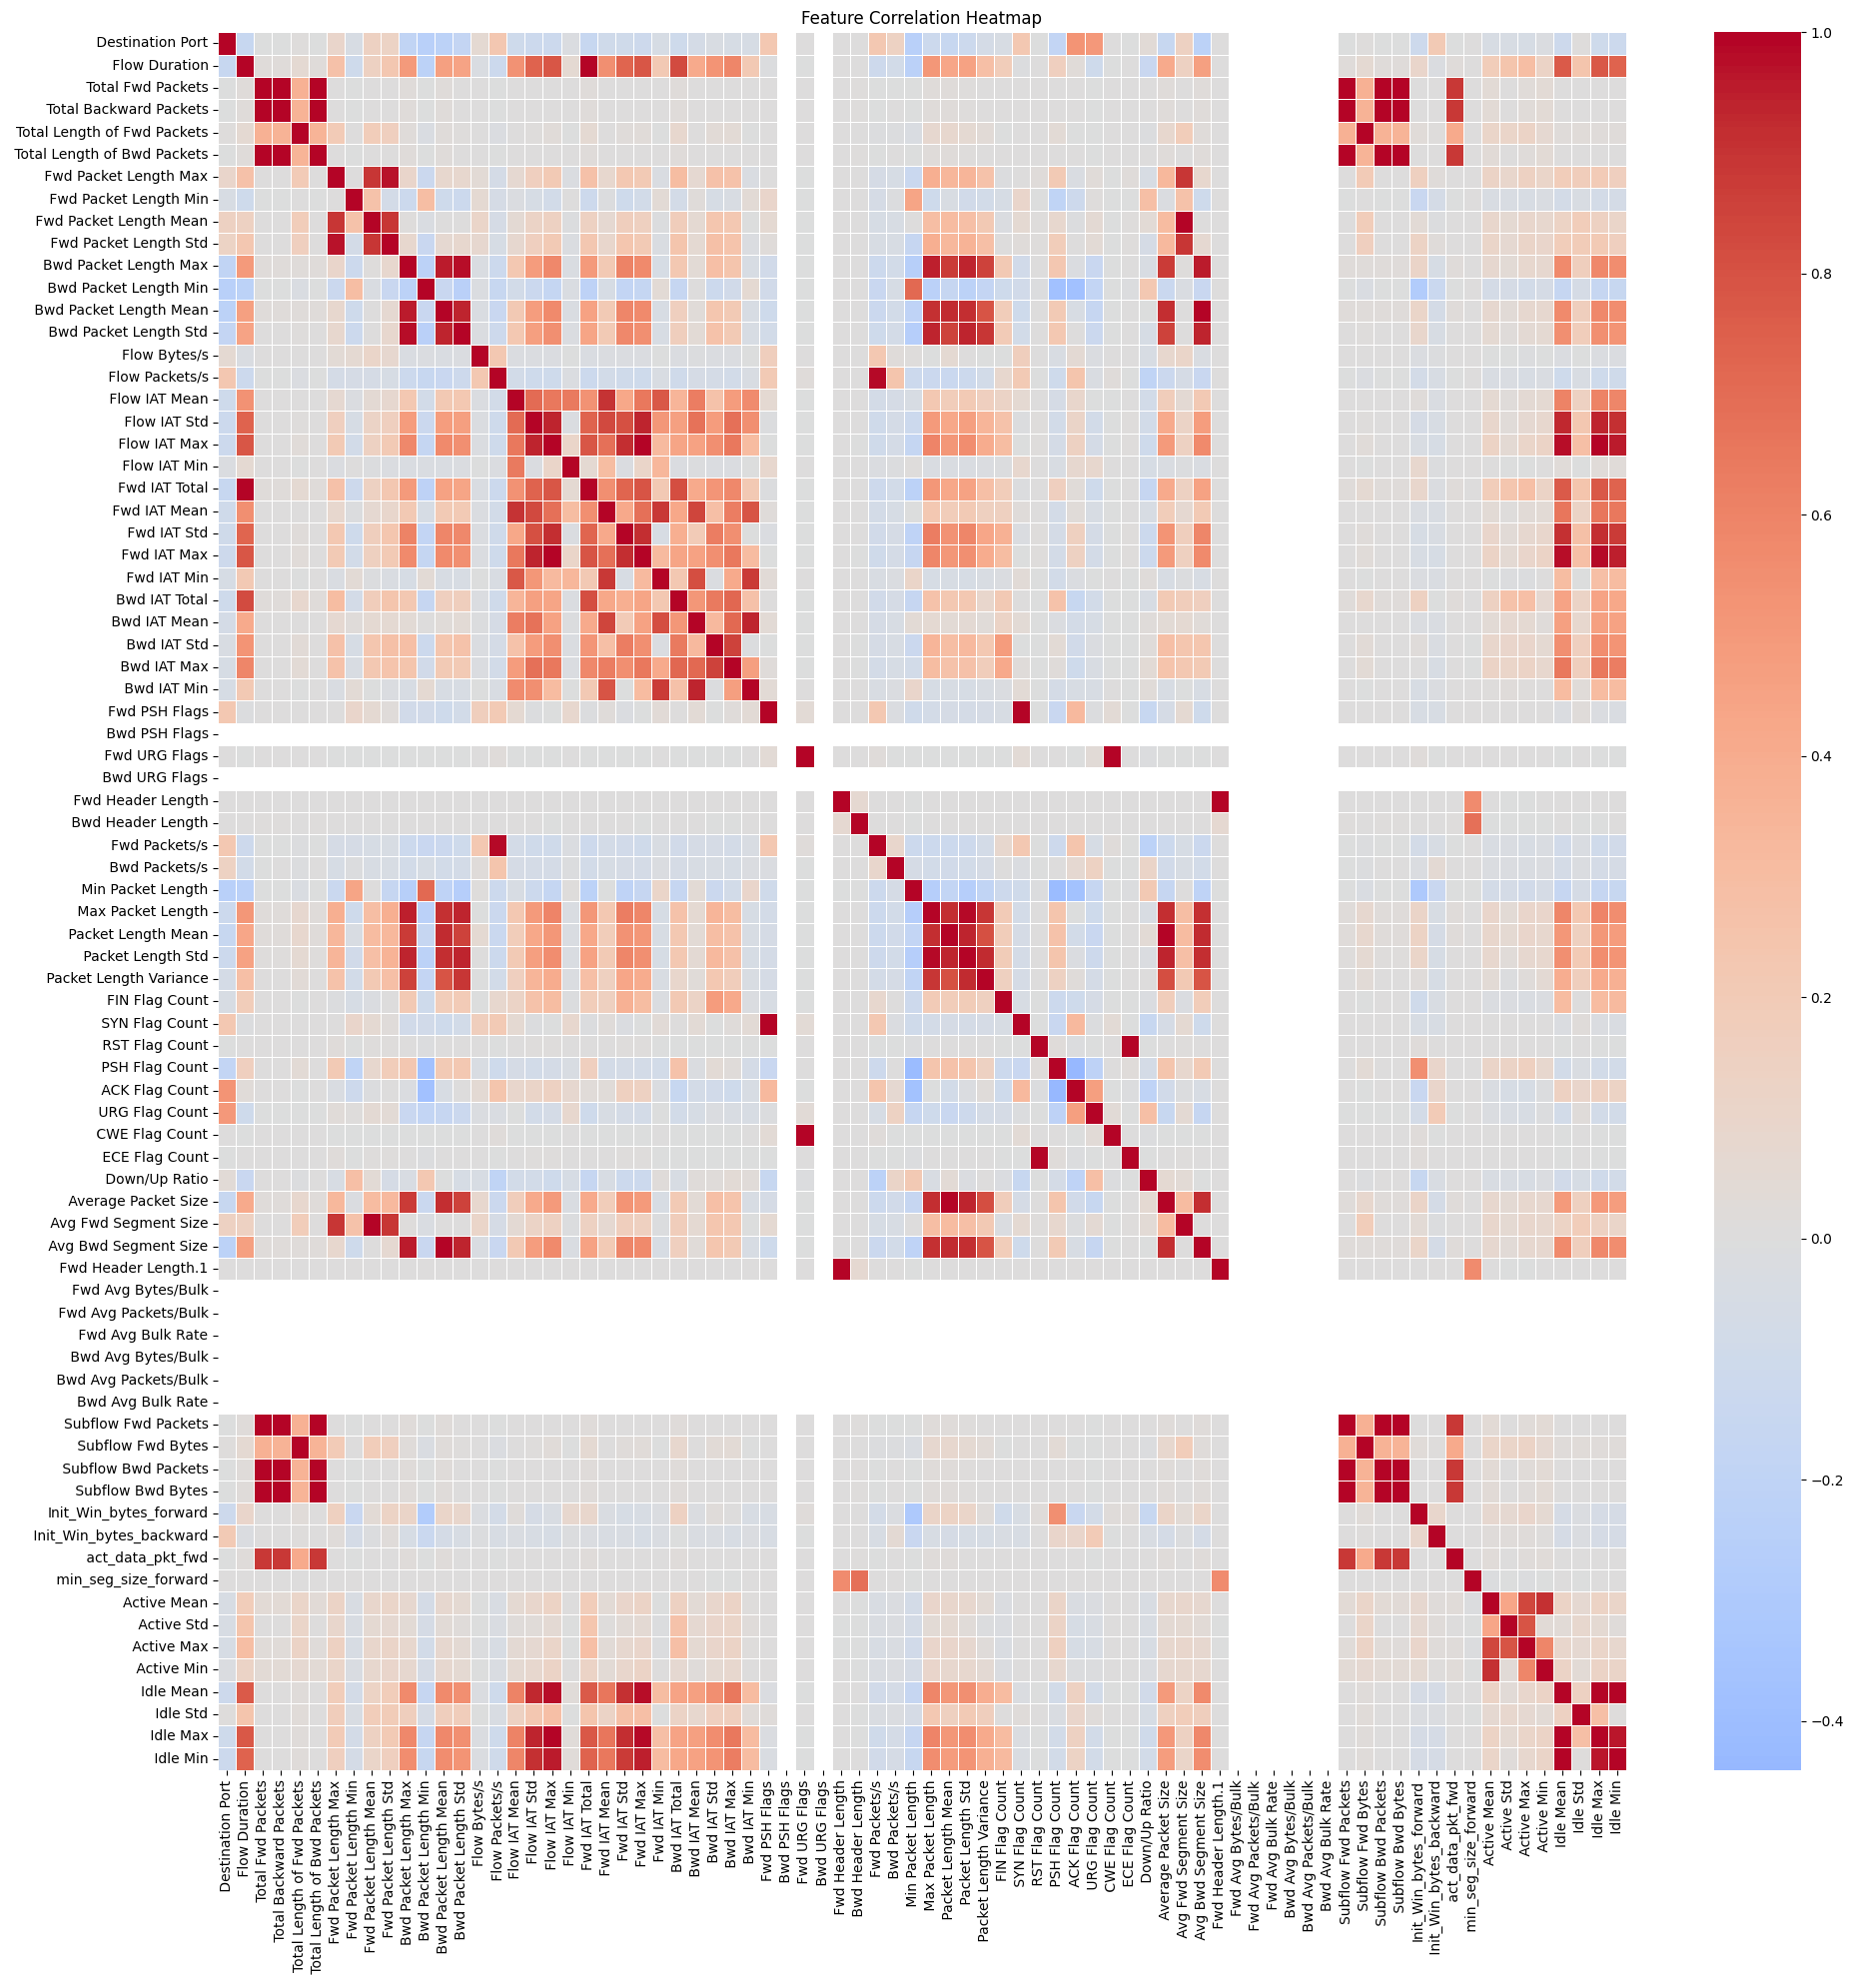

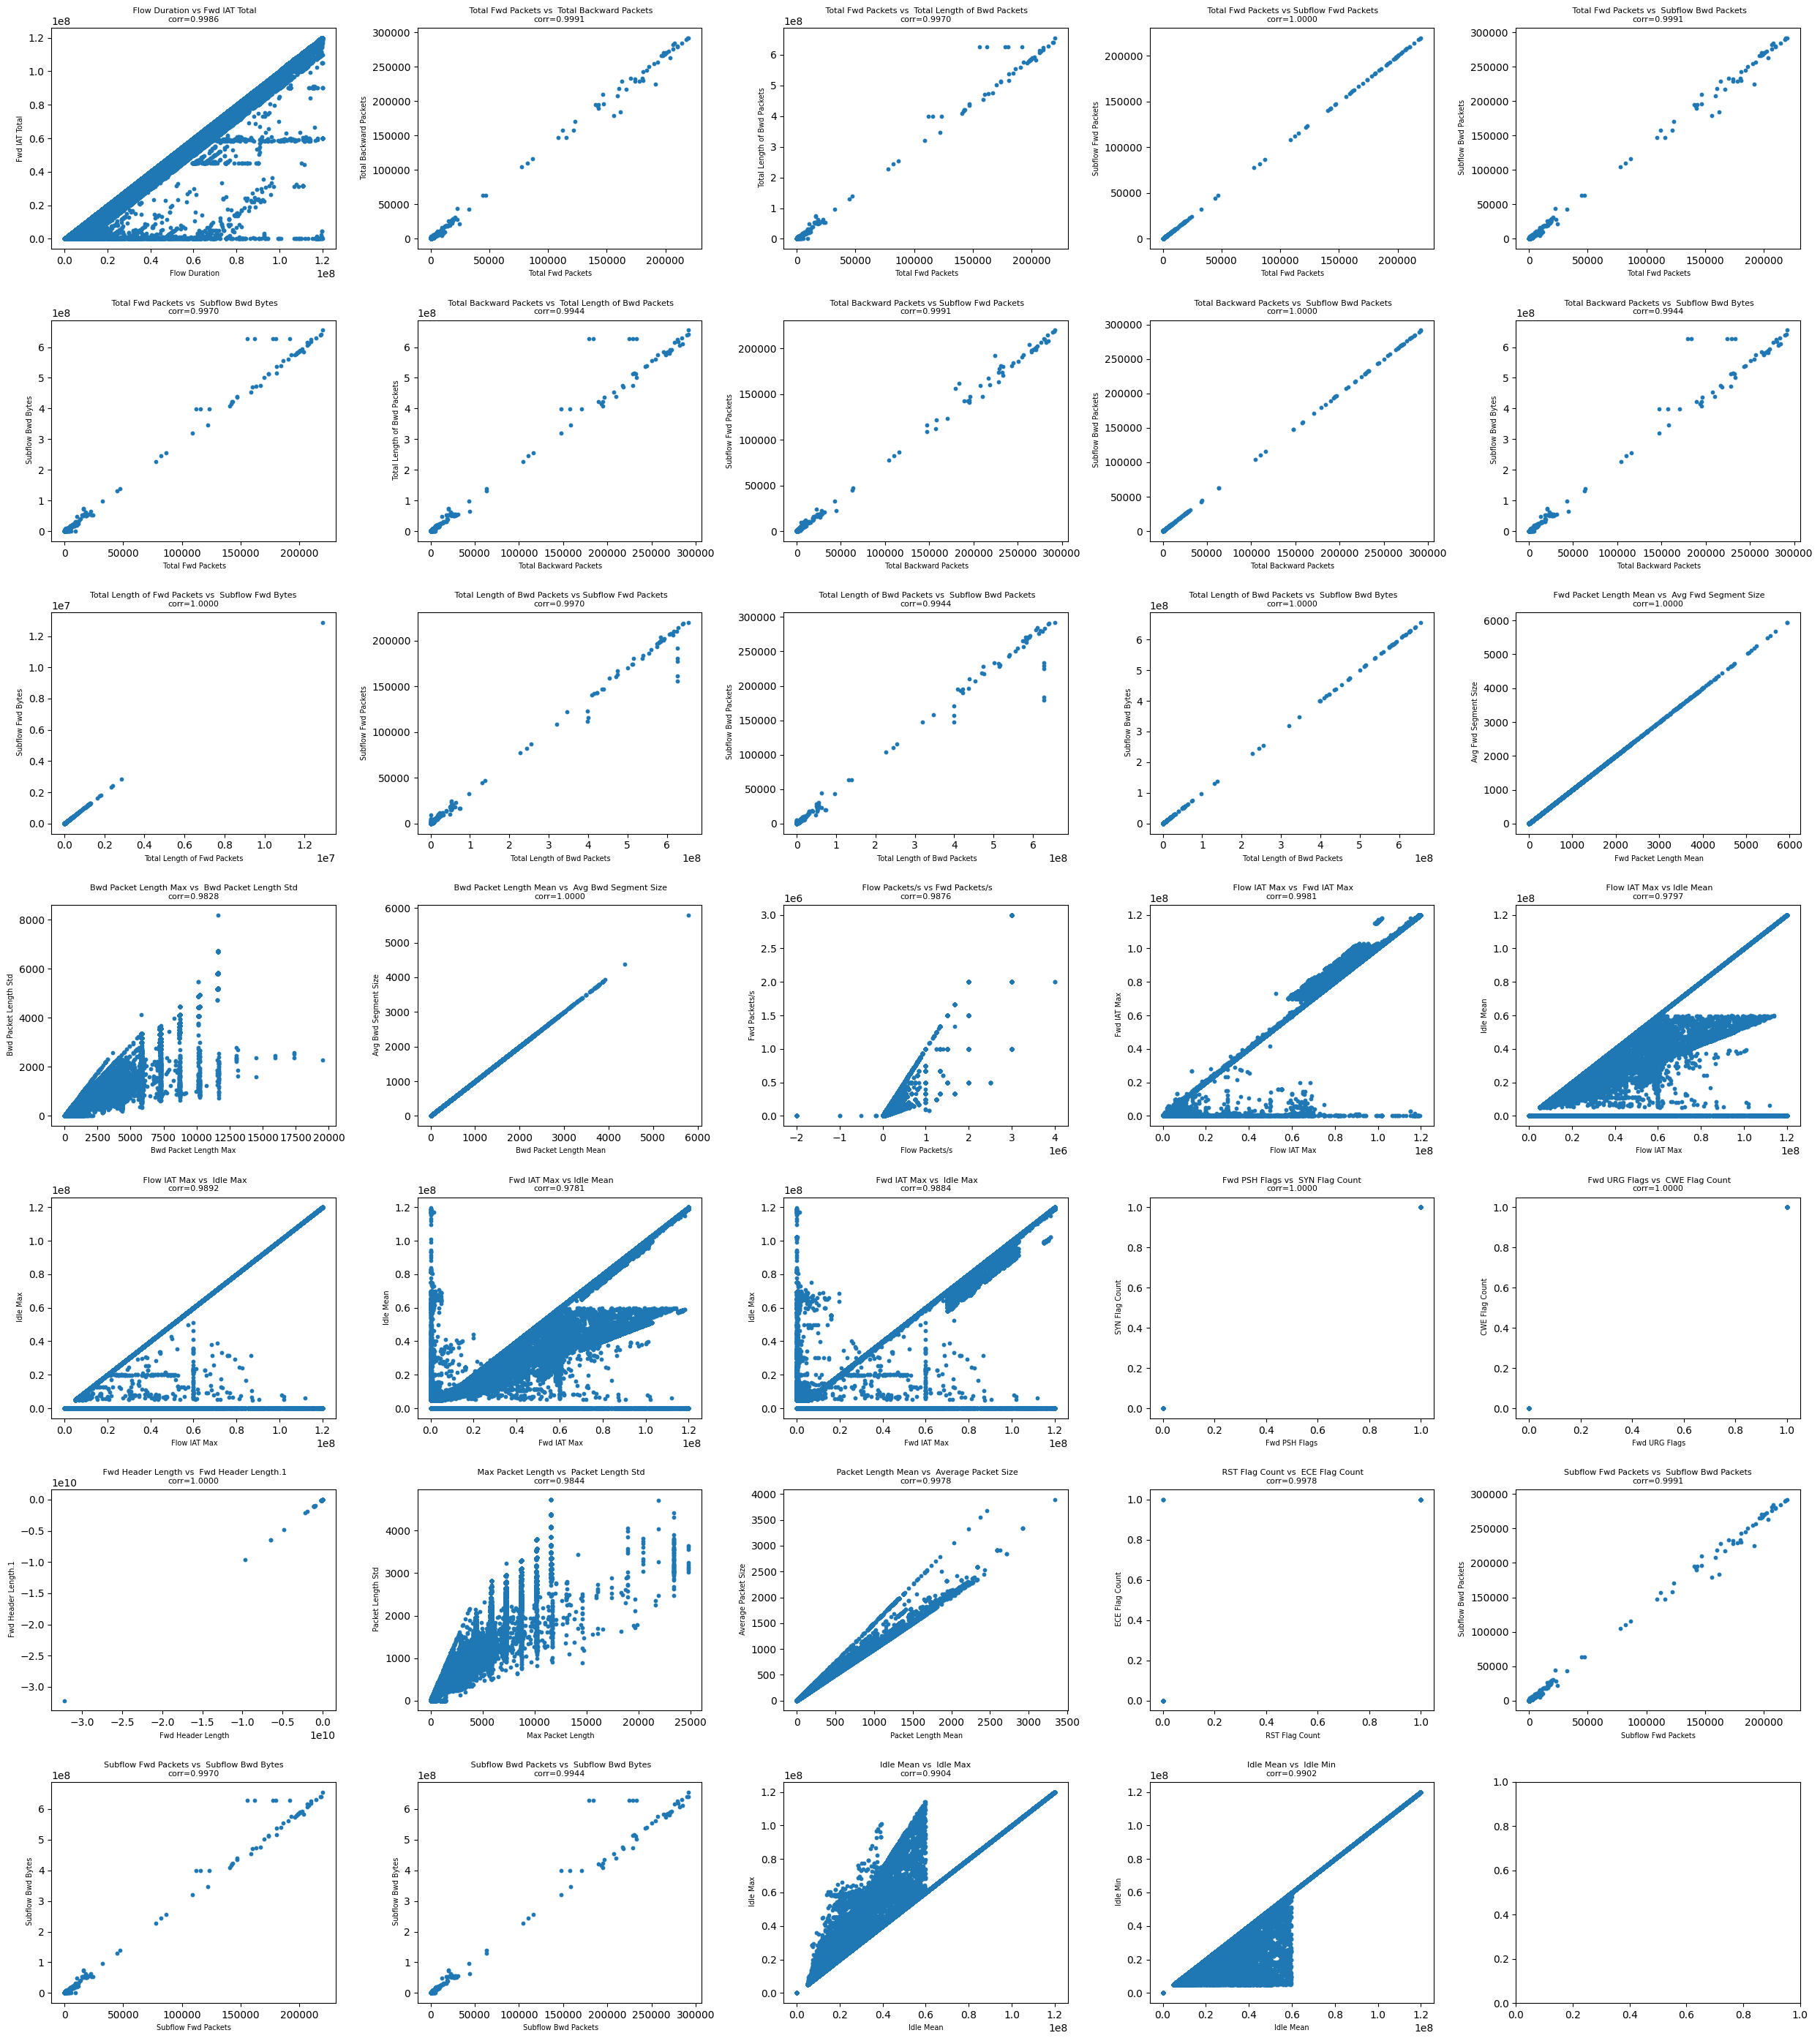

In [15]:
# test visualization
raw_df = load_raw()
plot_label_distribution(raw_df)
plot_correlation_heatmap(raw_df)
plot_correlated_pairs(raw_df, threshold=0.97)

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

X_resampled, y_resampled = resample(X_train, y_train)
X_fit_r, X_valid_r, y_fit_r, y_valid_r = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
)
#print(f"Original class distribution: {y_train.value_counts().to_dict()}")
#print(f"Original class distribution: {y_test.value_counts().to_dict()}")

#print(f"Resampled class distribution: {y_resampled.value_counts().to_dict()}")

Resampled class distribution:
Label
BENIGN                        138279
Bot                           138279
DDoS                          138279
DoS GoldenEye                 138279
DoS Hulk                      138279
DoS Slowhttptest              138279
DoS slowloris                 138279
FTP-Patator                   138279
Heartbleed                    138279
Infiltration                  138279
PortScan                      138279
SSH-Patator                   138279
Web Attack - Brute Force      138279
Web Attack - Sql Injection    138279
Web Attack - XSS              138279


# Logistic Regression

In [24]:
from src.models.logistic import (
    train_logistic_classifier,
    predict_labels,
    classification_report_for_model as lr_report,
)

In [25]:
lr_artifacts = train_logistic_classifier(
    X_train,
    y_train,
    random_state=42,
    max_iter=1000,
    verbose=1,
    solver="newton-cholesky",
)

Newton iter=1
  Check Convergence
    1. max |gradient| 0.07051766069257186 <= 0.0001 False
Newton iter=2
  Check Convergence
    1. max |gradient| 0.07703523291435642 <= 0.0001 False
Newton iter=3
  Check Convergence
    1. max |gradient| 0.11688287769219886 <= 0.0001 False
Newton iter=4
  Check Convergence
    1. max |gradient| 0.22258062261525505 <= 0.0001 False
Newton iter=5
  Check Convergence
    1. max |gradient| 0.12526998344300982 <= 0.0001 False
Newton iter=6
  Check Convergence
    1. max |gradient| 0.18783308529092396 <= 0.0001 False
Newton iter=7
  Check Convergence
    1. max |gradient| 0.15272388689803887 <= 0.0001 False
Newton iter=8
  Check Convergence
    1. max |gradient| 0.1513766108872491 <= 0.0001 False
Newton iter=9
  Check Convergence
    1. max |gradient| 0.14385770545652274 <= 0.0001 False
Newton iter=10
  Check Convergence
    1. max |gradient| 0.12687074396392992 <= 0.0001 False
Newton iter=11
  Check Convergence
    1. max |gradient| 0.09837556882793091 <= 


Classification Report:
== Logistic Regression ==
          accuracy: 0.8488
   macro_precision: 0.4187
      macro_recall: 0.9103
          macro_f1: 0.4970
weighted_precision: 0.9633
   weighted_recall: 0.8488
       weighted_f1: 0.8953

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.819     0.901    419297
                       Bot      0.013     0.985     0.025       391
                      DDoS      0.872     0.999     0.931     25603
             DoS GoldenEye      0.521     0.971     0.678      2057
                  DoS Hulk      0.832     0.997     0.907     34570
          DoS Slowhttptest      0.348     0.982     0.514      1046
             DoS slowloris      0.386     0.981     0.553      1077
               FTP-Patator      0.499     0.992     0.664      1187
                Heartbleed      0.500     1.000     0.667         2
              Infiltration      0.002     0.714     0.003         7
           

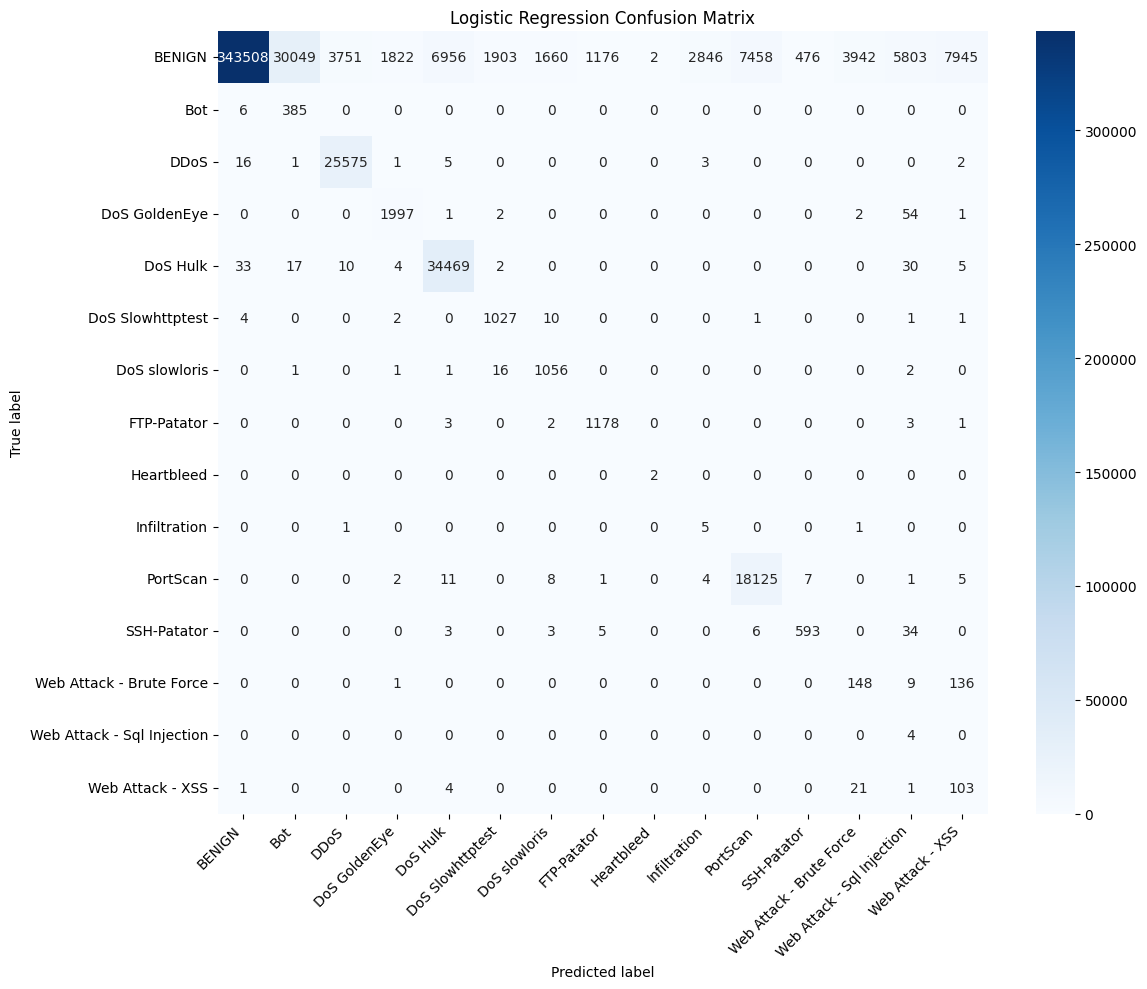

In [27]:
y_pred = predict_labels(lr_artifacts, X_test)
print("\nClassification Report:")
evaluate_and_visualize("Logistic Regression", y_true=y_test, y_pred=y_pred, labels=np.unique(y_test))
print()

# Random Forest

In [13]:
from src.models.rf import (
    train_rf_classifier,
    predict_labels,
    classification_report_for_model as rf_report,
)

In [15]:
rf_artifacts = train_rf_classifier(
    X_train,
    y_train,
    n_estimators=200,
    max_depth=100,
    random_state=42,
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.7min finished


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.2s finished



Classification Report:
== Random Forest ==
          accuracy: 0.9983
   macro_precision: 0.9387
      macro_recall: 0.8743
          macro_f1: 0.8984
weighted_precision: 0.9982
   weighted_recall: 0.9983
       weighted_f1: 0.9983

                            precision    recall  f1-score   support

                    BENIGN      0.999     0.999     0.999    419297
                       Bot      0.887     0.780     0.830       391
                      DDoS      1.000     1.000     1.000     25603
             DoS GoldenEye      0.999     0.991     0.995      2057
                  DoS Hulk      0.998     0.997     0.997     34570
          DoS Slowhttptest      0.990     0.993     0.991      1046
             DoS slowloris      0.997     0.994     0.995      1077
               FTP-Patator      1.000     0.997     0.999      1187
                Heartbleed      1.000     1.000     1.000         2
              Infiltration      1.000     0.714     0.833         7
                 

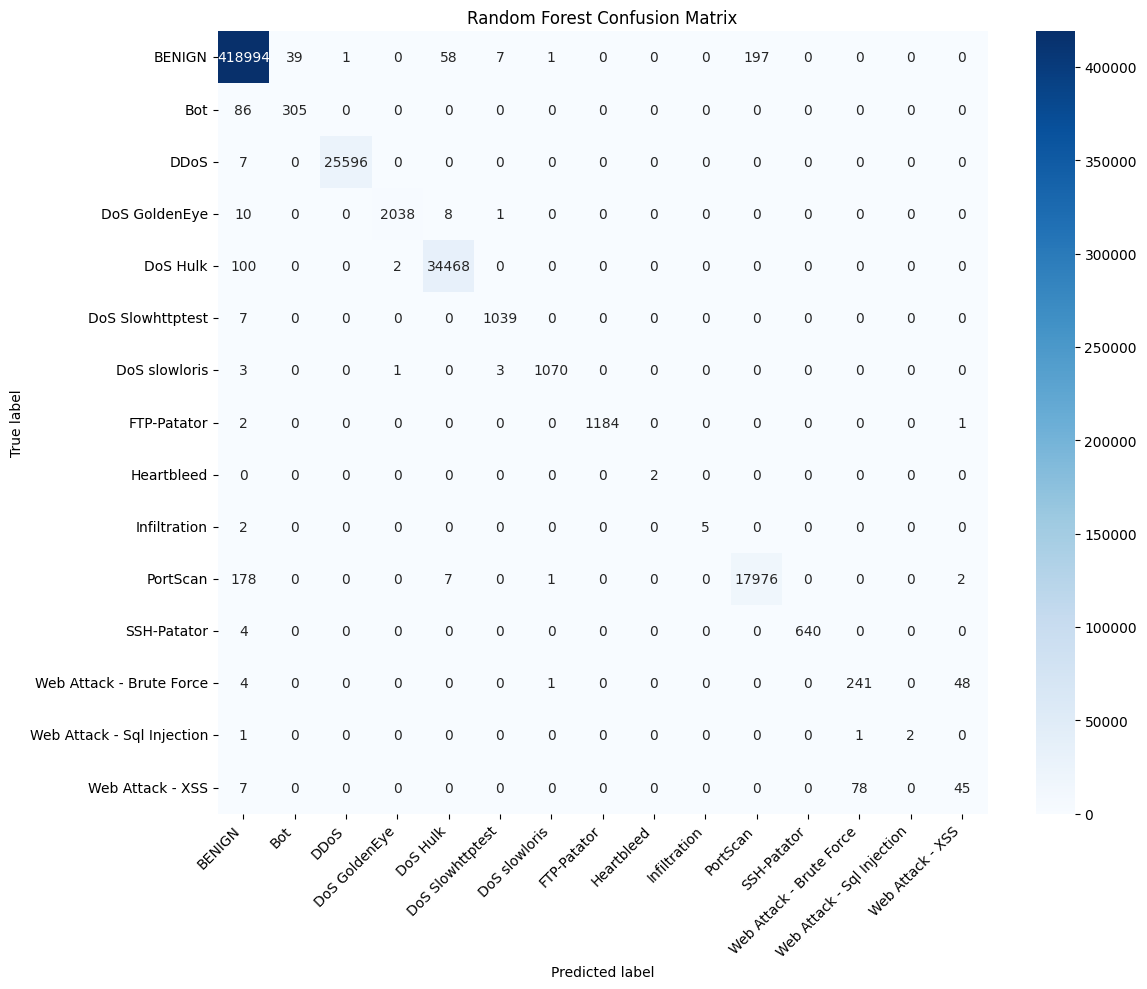

In [17]:
y_pred = predict_labels(rf_artifacts, X_test)
print("\nClassification Report:")
evaluate_and_visualize(model_name="Random Forest", y_true=y_test, y_pred=y_pred, labels=np.unique(y_test))
print()

# LightGBM

In [18]:
from src.models.lgbm import (
    train_lightgbm_classifier,
    predict_labels,
    classification_report_for_model as lgbm_report
)

In [19]:
lgbm_artifacts = train_lightgbm_classifier(
    X_fit,
    y_fit,
    X_valid=X_valid,
    y_valid=y_valid,
    class_weight="balanced",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=0,
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf



Classification Report:
== LGBM ==
          accuracy: 0.9987
   macro_precision: 0.9189
      macro_recall: 0.9069
          macro_f1: 0.9052
weighted_precision: 0.9988
   weighted_recall: 0.9987
       weighted_f1: 0.9987

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.999     0.999    419297
                       Bot      0.709     0.964     0.817       391
                      DDoS      1.000     1.000     1.000     25603
             DoS GoldenEye      0.994     0.995     0.995      2057
                  DoS Hulk      0.998     1.000     0.999     34570
          DoS Slowhttptest      0.988     0.993     0.990      1046
             DoS slowloris      0.990     0.994     0.992      1077
               FTP-Patator      1.000     0.997     0.999      1187
                Heartbleed      1.000     1.000     1.000         2
              Infiltration      1.000     1.000     1.000         7
                  PortScan

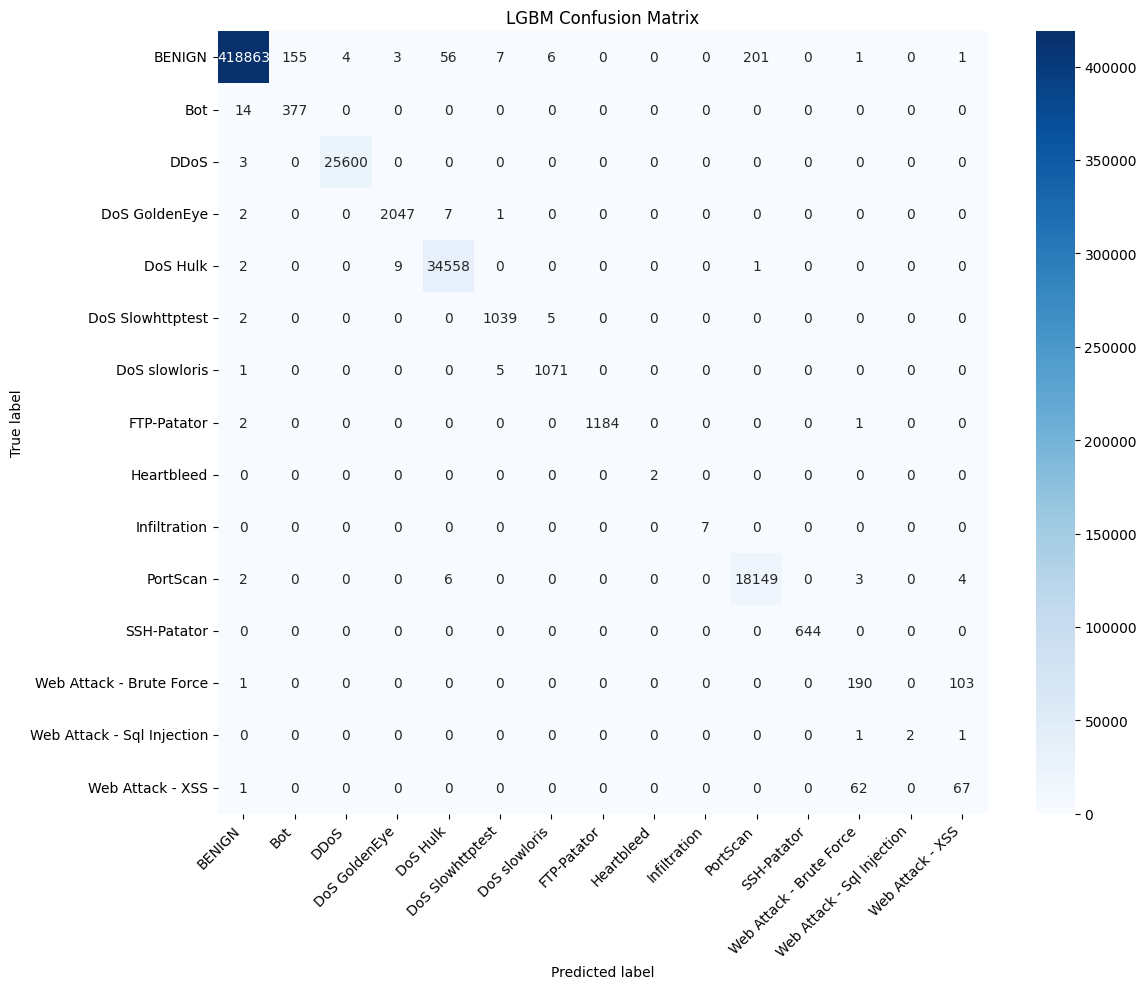

In [20]:
y_pred = predict_labels(lgbm_artifacts, X_test)
print("\nClassification Report:")
evaluate_and_visualize("LGBM", y_true=y_test, y_pred=y_pred, labels=np.unique(y_test))
print()

# Multi Layer Perceptron

In [21]:
from src.models.mlp import (
    train_mlp_classifier,
    classification_report_for_model as mlp_report,
    predict_labels
)

In [22]:
mlp_artifacts = train_mlp_classifier(
    X_fit_r,
    y_fit_r,
    X_valid=X_valid_r,
    y_valid=y_valid_r,
    epochs=50,
    verbose=1,
    dropout_rate=0.15,
    batch_size=512,
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9139 - loss: 0.1950 - val_accuracy: 0.9057 - val_loss: 0.2436
Epoch 2/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9306 - loss: 0.1435 - val_accuracy: 0.9210 - val_loss: 0.1945
Epoch 3/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9346 - loss: 0.1347 - val_accuracy: 0.9190 - val_loss: 0.2049
Epoch 4/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9373 - loss: 0.1301 - val_accuracy: 0.9225 - val_loss: 0.1927
Epoch 5/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9380 - loss: 0.1273 - val_accuracy: 0.9236 - val_loss: 0.1840
Epoch 6/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9384 - loss: 0.1261 - val_accuracy: 0.9251 - val_loss: 0.1657
Epoch 7/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9384 - loss: 0.1259 - val_accuracy: 0.9219 - val_loss: 0.1570
Epoch 8/50
3241/3241 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9396 - lo

== MLP ==
          accuracy: 0.9505
   macro_precision: 0.4996
      macro_recall: 0.9189
          macro_f1: 0.5576
weighted_precision: 0.9790
   weighted_recall: 0.9505
       weighted_f1: 0.9623

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.942     0.970    419297
                       Bot      0.057     0.990     0.108       391
                      DDoS      0.950     0.999     0.974     25603
             DoS GoldenEye      0.875     0.984     0.927      2057
                  DoS Hulk      0.940     0.998     0.968     34570
          DoS Slowhttptest      0.797     0.992     0.884      1046
             DoS slowloris      0.731     0.990     0.841      1077
               FTP-Patator      0.829     0.992     0.903      1187
                Heartbleed      0.250     1.000     0.400         2
              Infiltration      0.008     0.857     0.016         7
                  PortScan      0.729     0.998    

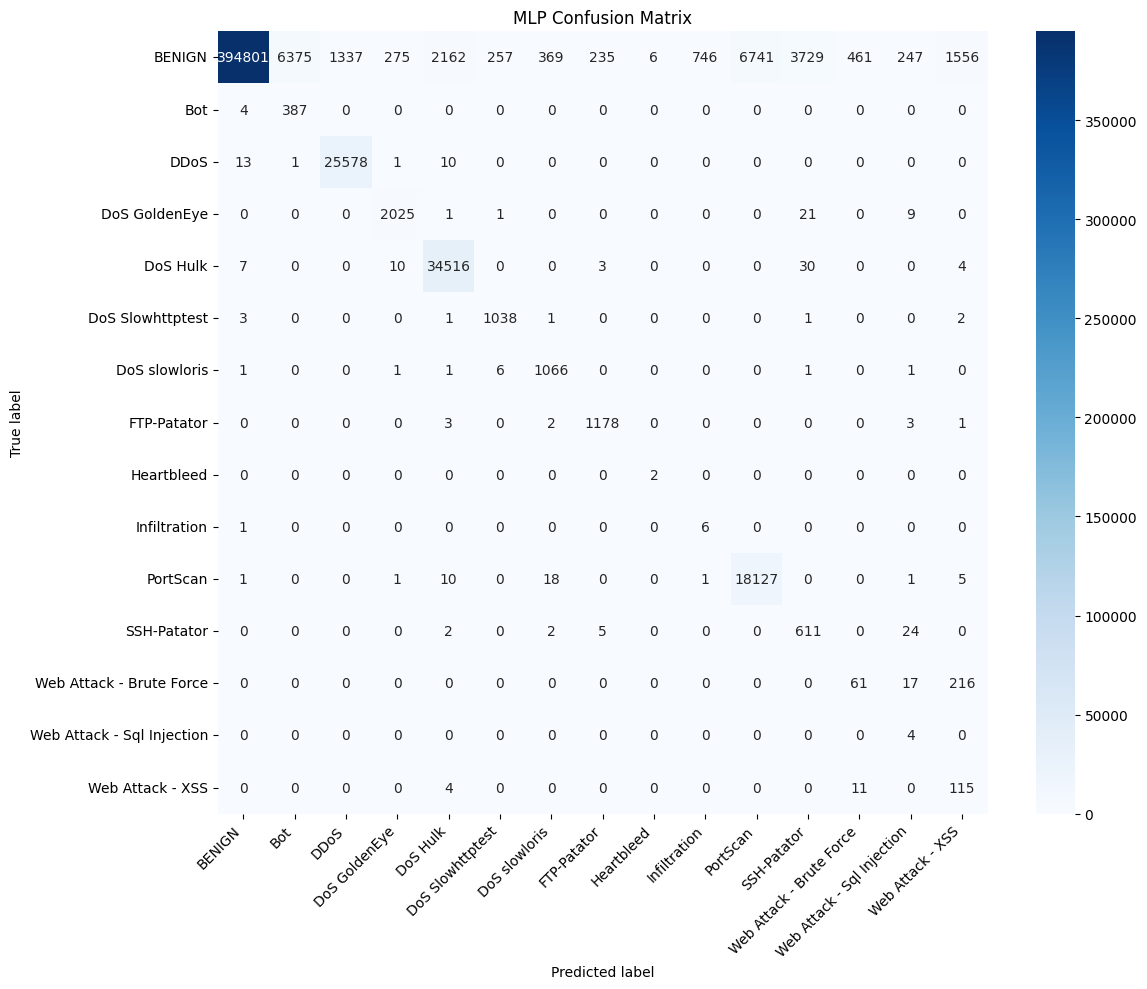

DONE


In [23]:
from src.models.evaluation import evaluate_and_visualize
y_pred = predict_labels(mlp_artifacts, X_test)
evaluate_and_visualize(model_name="MLP", y_true=y_test, y_pred=y_pred, labels=np.unique(y_test))
print("DONE")